<a href="https://colab.research.google.com/github/justamy20/finalterm-machine-learning/blob/main/regression_song_year.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 End-to-End Regression Pipeline: Song Release Year Prediction

**UAS Individual Task - Machine Learning**

**Identitas Mahasiswa:**
* **Nama:** Syeh Khatami
* **NIM:** 101032300157
* **Kelas:** S1 Teknik Komputer - TK-47-04

**Dataset:** `midterm-regresi-dataset.csv`  
**Task:** Predict the release year of a song based on audio features  
**Framework:** PyTorch (Deep Learning) + Scikit-learn (Baseline ML)  
**Tools:** Optuna (Hyperparameter Tuning), MLflow (Tracking), LIME (Interpretability)

---

## Pipeline Overview
1. Data Loading & Exploration (EDA)
2. Data Preprocessing & Feature Engineering
3. Baseline ML Model (Linear Regression)
4. Deep Learning Model (PyTorch MLP)
5. Hyperparameter Tuning with Optuna
6. Evaluation & Interpretability with LIME
7. MLflow Tracking
8. Conclusion

## ⚙️ Install Dependencies

In [ ]:
!pip install optuna mlflow lime torch scikit-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 3.9 MB/s eta 0:00:00
   ━━━

## 📂 Upload Dataset
Upload file `midterm-regresi-dataset.csv` menggunakan cell di bawah ini.

In [ ]:
from google.colab import files
uploaded = files.upload()
print("✅ File berhasil diupload:", list(uploaded.keys()))

Saving midterm-regresi-dataset.csv to midterm-regresi-dataset.csv
✅ File berhasil diupload: ['midterm-regresi-dataset.csv']


---
## 1. 📦 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.pytorch

# LIME
import lime
import lime.lime_tabular

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries loaded | Device: {device}")

✅ Libraries loaded | Device: cpu


---
## 2. 📊 Data Loading & Exploratory Data Analysis (EDA)

In [ ]:
# Load dataset
# Kolom pertama adalah target (tahun rilis), sisanya adalah fitur audio
df = pd.read_csv('midterm-regresi-dataset.csv', header=None)

# Beri nama kolom
n_features = df.shape[1] - 1
df.columns = ['year'] + [f'feature_{i+1}' for i in range(n_features)]

print(f"📐 Shape dataset: {df.shape}")
print(f"🎯 Target: year | Range: {df['year'].min()} - {df['year'].max()}")
print(f"🔢 Jumlah fitur: {n_features}")
df.head()

📐 Shape dataset: (515345, 91)
🎯 Target: year | Range: 1922 - 2011
🔢 Jumlah fitur: 90


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [ ]:
# Statistik deskriptif
print("=" * 50)
print("📈 STATISTIK DESKRIPTIF")
print("=" * 50)
df.describe().T.head(10)

📈 STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
year,515345.0,1998.397082,10.931046,1922.00000,1994.00000,2002.00000,2006.00000,2011.00000
feature_1,515345.0,43.387126,6.067558,1.74900,39.95469,44.25850,47.83389,61.97014
feature_2,515345.0,1.289554,51.580351,-337.09250,-26.05952,8.41785,36.12401,384.06573
feature_3,515345.0,8.658347,35.268585,-301.00506,-11.46271,10.47632,29.76482,322.85143
feature_4,515345.0,1.164124,16.322790,-154.18358,-8.48750,-0.65284,8.78754,335.77182
feature_5,515345.0,-6.553601,22.860785,-181.95337,-20.66645,-6.00777,7.74187,262.06887
feature_6,515345.0,-9.521975,12.857751,-81.79429,-18.44099,-11.18839,-2.38896,166.23689
feature_7,515345.0,-2.391089,14.571873,-188.21400,-10.78060,-2.04667,6.50858,172.40268
feature_8,515345.0,-1.793236,7.963827,-72.50385,-6.46842,-1.73645,2.91345,126.74127
feature_9,515345.0,3.727876,10.582861,-126.47904,-2.29366,3.82231,9.96182,146.29795


In [ ]:
# Cek missing values
missing = df.isnull().sum()
print(f"❓ Total missing values: {missing.sum()}")
if missing.sum() == 0:
    print("✅ Tidak ada missing values!")

❓ Total missing values: 0
✅ Tidak ada missing values!


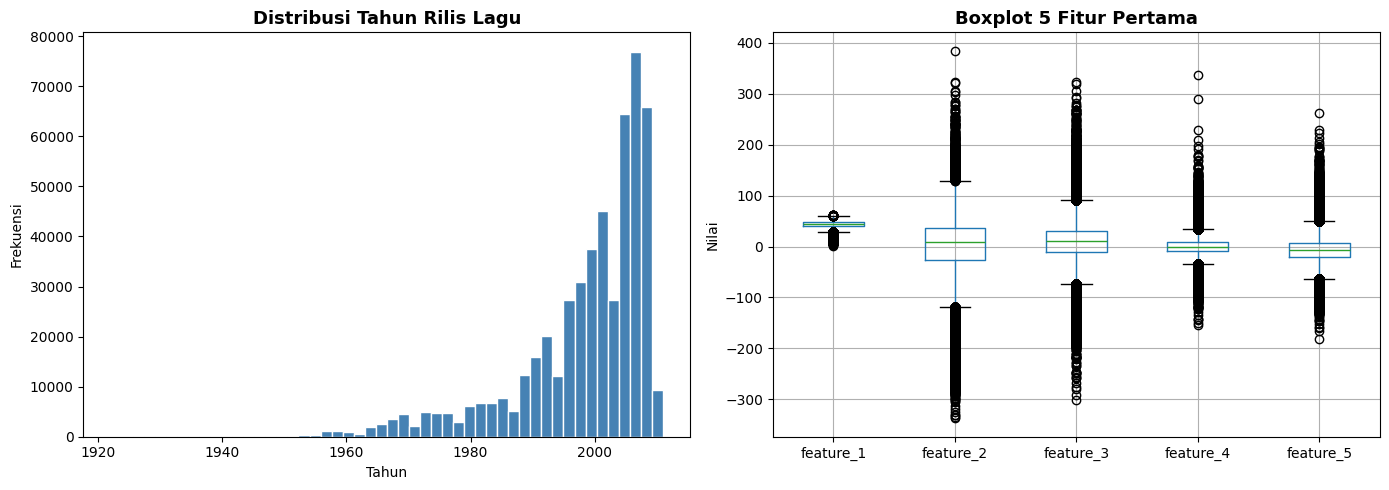

✅ Plot EDA disimpan sebagai eda_plots.png


In [ ]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['year'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Tahun Rilis Lagu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Frekuensi')

# Boxplot beberapa fitur pertama
df[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']].boxplot(ax=axes[1])
axes[1].set_title('Boxplot 5 Fitur Pertama', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Plot EDA disimpan sebagai eda_plots.png")

---
## 3. 🔧 Data Preprocessing & Feature Engineering

In [ ]:
# Pisahkan fitur dan target
X = df.drop('year', axis=1).values
y = df['year'].values.astype(np.float32)

print(f"📌 Shape X: {X.shape}")
print(f"📌 Shape y: {y.shape}")

📌 Shape X: (515345, 90)
📌 Shape y: (515345,)


In [ ]:
# Hapus outlier menggunakan IQR pada target
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y >= lower_bound) & (y <= upper_bound)
X_clean = X[mask]
y_clean = y[mask]

print(f"📊 Data sebelum outlier removal: {X.shape[0]} baris")
print(f"📊 Data setelah outlier removal: {X_clean.shape[0]} baris")
print(f"🗑️  Outliers removed: {X.shape[0] - X_clean.shape[0]} baris")

📊 Data sebelum outlier removal: 515345 baris
📊 Data setelah outlier removal: 485642 baris
🗑️  Outliers removed: 29703 baris


In [ ]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Feature Scaling dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

print(f"✅ Train size: {X_train_scaled.shape}")
print(f"✅ Test size:  {X_test_scaled.shape}")

✅ Train size: (388513, 90)
✅ Test size:  (97129, 90)


---
## 4. 📐 Baseline Model: Linear Regression

In [ ]:
# Melatih model baseline sederhana terlebih dahulu
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("=" * 45)
print("📊 BASELINE: LINEAR REGRESSION")
print("=" * 45)
print(f"  MSE  : {mse_lr:.4f}")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

📊 BASELINE: LINEAR REGRESSION
  MSE  : 45.6235
  RMSE : 6.7545
  MAE  : 5.1911
  R²   : 0.2406


---
## 5. 🧠 Deep Learning Model: PyTorch MLP

In [ ]:
# Konversi ke PyTorch Tensor
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"✅ DataLoader siap | Batch size: 256")
print(f"   Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

✅ DataLoader siap | Batch size: 256
   Train batches: 1518 | Test batches: 380


In [ ]:
# Definisi arsitektur MLP
class SongYearMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super(SongYearMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # Output layer (regresi)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
print(f"✅ Model MLP didefinisikan | Input dim: {input_dim}")

✅ Model MLP didefinisikan | Input dim: 90


In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=50, verbose=True):
    """Fungsi training model PyTorch."""
    model.to(device)
    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

    return train_losses


def evaluate_model(model, X_test_tensor, y_test):
    """Evaluasi model dan return metrik regresi."""
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor.to(device)).cpu().numpy().flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return mse, rmse, mae, r2, y_pred

print("✅ Fungsi training dan evaluasi siap")

✅ Fungsi training dan evaluasi siap


In [ ]:
# Training MLP awal (sebelum tuning)
print("🚀 Training MLP (arsitektur awal)...")
model_initial = SongYearMLP(input_dim, hidden_dims=[256, 128, 64], dropout_rate=0.3)
optimizer_init = optim.Adam(model_initial.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses_initial = train_model(model_initial, train_loader, optimizer_init, criterion, epochs=50)

mse_i, rmse_i, mae_i, r2_i, _ = evaluate_model(model_initial, X_test_tensor, y_test)
print("\n📊 INITIAL MLP RESULTS:")
print(f"  MSE  : {mse_i:.4f}")
print(f"  RMSE : {rmse_i:.4f}")
print(f"  MAE  : {mae_i:.4f}")
print(f"  R²   : {r2_i:.4f}")

🚀 Training MLP (arsitektur awal)...
  Epoch [10/50] | Loss: 30273.7049
  Epoch [20/50] | Loss: 28550.3152
  Epoch [30/50] | Loss: 27453.6811
  Epoch [40/50] | Loss: 26399.7420
  Epoch [50/50] | Loss: 25726.8568

📊 INITIAL MLP RESULTS:
  MSE  : 11684.7119
  RMSE : 108.0958
  MAE  : 17.7124
  R²   : -193.4902


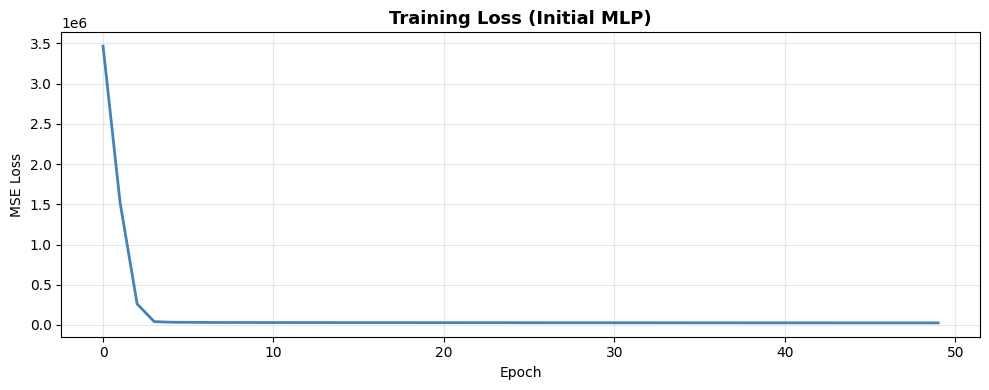

In [ ]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses_initial, color='steelblue', linewidth=2)
plt.title('Training Loss (Initial MLP)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=100)
plt.show()

---
## 6. 🔬 Hyperparameter Tuning dengan Optuna

In [20]:
def objective(trial):
    """Fungsi objective untuk Optuna."""
    # Hyperparameter search space
    n_layers    = trial.suggest_int('n_layers', 2, 4)
    dropout     = trial.suggest_float('dropout', 0.1, 0.5)
    lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    hidden_dims = [trial.suggest_categorical(f'hidden_{i}', [64, 128, 256, 512])
                   for i in range(n_layers)]

    model = SongYearMLP(input_dim, hidden_dims, dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Training singkat untuk evaluasi cepat Optuna (Cukup 5 putaran saja biar cepat)
    model.train()
    for epoch in range(5):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    # Evaluasi pada test set
    _, rmse, _, _, _ = evaluate_model(model, X_test_tensor, y_test)
    return rmse


print("🔍 Menjalankan Optuna hyperparameter search (15 trials)...")
study = optuna.create_study(direction='minimize')
# N_trials diubah ke 15 sesuai permintaanmu
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\n✅ Optuna selesai!")
print(f"   Best RMSE : {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

🔍 Menjalankan Optuna hyperparameter search (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Optuna selesai!
   Best RMSE : 10.6612
   Best params: {'n_layers': 4, 'dropout': 0.28075988252496115, 'lr': 0.0020739888341483478, 'hidden_0': 128, 'hidden_1': 256, 'hidden_2': 256, 'hidden_3': 512}


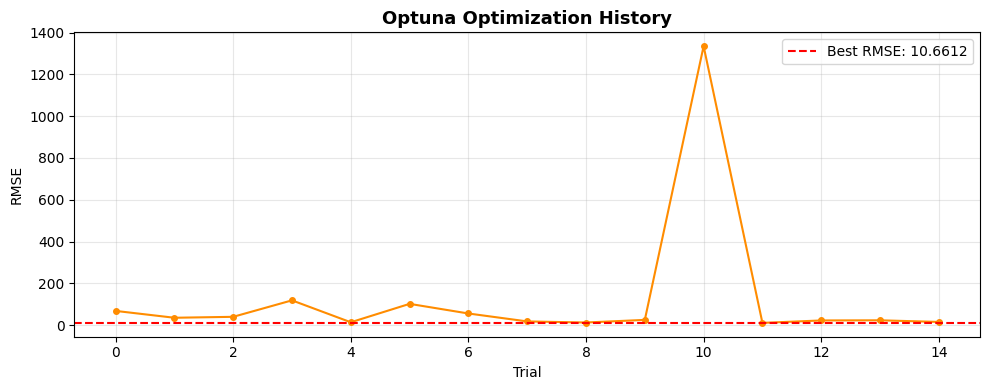

In [21]:
# Visualisasi history Optuna
trial_values = [t.value for t in study.trials if t.value is not None]
plt.figure(figsize=(10, 4))
plt.plot(trial_values, marker='o', markersize=4, color='darkorange', linewidth=1.5)
plt.axhline(study.best_value, color='red', linestyle='--', label=f'Best RMSE: {study.best_value:.4f}')
plt.title('Optuna Optimization History', fontsize=13, fontweight='bold')
plt.xlabel('Trial')
plt.ylabel('RMSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=100)
plt.show()

In [22]:
# Training model terbaik dengan hyperparameter dari Optuna
best_params = study.best_params
n_layers    = best_params['n_layers']
best_hidden = [best_params[f'hidden_{i}'] for i in range(n_layers)]
best_dropout = best_params['dropout']
best_lr     = best_params['lr']

print(f"🚀 Training Best MLP | Layers: {best_hidden} | Dropout: {best_dropout:.3f} | LR: {best_lr:.6f}")

best_model = SongYearMLP(input_dim, best_hidden, best_dropout)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_lr)

losses_best = train_model(best_model, train_loader, best_optimizer, criterion, epochs=100)

mse_b, rmse_b, mae_b, r2_b, y_pred_best = evaluate_model(best_model, X_test_tensor, y_test)
print("\n📊 BEST MLP (AFTER OPTUNA) RESULTS:")
print(f"  MSE  : {mse_b:.4f}")
print(f"  RMSE : {rmse_b:.4f}")
print(f"  MAE  : {mae_b:.4f}")
print(f"  R²   : {r2_b:.4f}")

🚀 Training Best MLP | Layers: [128, 256, 256, 512] | Dropout: 0.281 | LR: 0.002074
  Epoch [10/100] | Loss: 3846.9882
  Epoch [20/100] | Loss: 3113.2055
  Epoch [30/100] | Loss: 3028.3816
  Epoch [40/100] | Loss: 3006.3312
  Epoch [50/100] | Loss: 2981.7425
  Epoch [60/100] | Loss: 2941.5582
  Epoch [70/100] | Loss: 2905.0140
  Epoch [80/100] | Loss: 2875.6364
  Epoch [90/100] | Loss: 2839.8127
  Epoch [100/100] | Loss: 2815.1302

📊 BEST MLP (AFTER OPTUNA) RESULTS:
  MSE  : 50.3678
  RMSE : 7.0970
  MAE  : 5.7714
  R²   : 0.1616


---
## 7. 📈 Evaluasi & Perbandingan Model

In [23]:
# Tabel perbandingan performa
results = pd.DataFrame({
    'Model': ['Linear Regression', 'MLP (Initial)', 'MLP (Optuna Tuned)'],
    'MSE':   [mse_lr,  mse_i,  mse_b],
    'RMSE':  [rmse_lr, rmse_i, rmse_b],
    'MAE':   [mae_lr,  mae_i,  mae_b],
    'R²':    [r2_lr,   r2_i,   r2_b]
})

print("=" * 65)
print("📊 PERBANDINGAN PERFORMA MODEL")
print("=" * 65)
print(results.to_string(index=False))
print("=" * 65)

📊 PERBANDINGAN PERFORMA MODEL
             Model          MSE       RMSE       MAE          R²
 Linear Regression    45.623486   6.754516  5.191123    0.240604
     MLP (Initial) 11684.711914 108.095846 17.712374 -193.490219
MLP (Optuna Tuned)    50.367847   7.097031  5.771431    0.161635


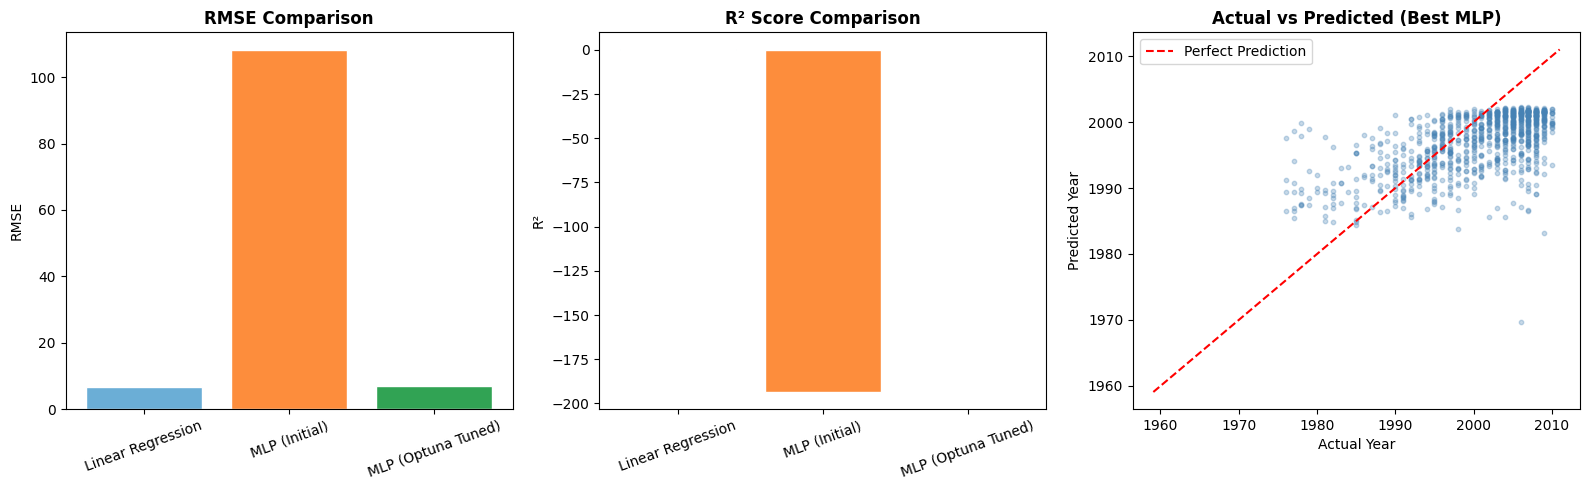

✅ Plot perbandingan disimpan


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart RMSE
colors = ['#6baed6', '#fd8d3c', '#31a354']
axes[0].bar(results['Model'], results['RMSE'], color=colors, edgecolor='white')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

# Bar chart R²
axes[1].bar(results['Model'], results['R²'], color=colors, edgecolor='white')
axes[1].set_title('R² Score Comparison', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

# Actual vs Predicted (Best Model)
axes[2].scatter(y_test[:1000], y_pred_best[:1000], alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[2].set_title('Actual vs Predicted (Best MLP)', fontweight='bold')
axes[2].set_xlabel('Actual Year')
axes[2].set_ylabel('Predicted Year')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Plot perbandingan disimpan")

---
## 8. 🔍 Interpretability dengan LIME

In [25]:
# LIME Explainer
def predict_fn(X_input):
    """Wrapper prediksi untuk LIME."""
    best_model.eval()
    with torch.no_grad():
        tensor = torch.FloatTensor(X_input).to(device)
        output = best_model(tensor).cpu().numpy().flatten()
    return output

feature_names = [f'feature_{i+1}' for i in range(input_dim)]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    mode='regression',
    random_state=42
)

# Jelaskan satu sample
sample_idx = 0
explanation = explainer.explain_instance(
    X_test_scaled[sample_idx],
    predict_fn,
    num_features=10
)

print(f"🔍 LIME Explanation untuk sampel index {sample_idx}")
print(f"   Actual Year   : {y_test[sample_idx]:.0f}")
print(f"   Predicted Year: {predict_fn(X_test_scaled[sample_idx:sample_idx+1])[0]:.2f}")
print(f"\n   Top 10 fitur berpengaruh:")
for feat, weight in explanation.as_list():
    direction = '⬆️' if weight > 0 else '⬇️'
    print(f"   {direction} {feat}: {weight:.4f}")

🔍 LIME Explanation untuk sampel index 0
   Actual Year   : 1999
   Predicted Year: 2000.11

   Top 10 fitur berpengaruh:
   ⬇️ feature_1 <= -0.56: -6.5063
   ⬆️ feature_2 <= -0.53: 3.2472
   ⬆️ feature_3 <= -0.57: 1.8897
   ⬆️ feature_6 <= -0.69: 1.2023
   ⬆️ feature_19 > 0.43: 0.8921
   ⬇️ feature_78 > 0.51: -0.8835
   ⬇️ feature_16 <= -0.64: -0.8706
   ⬆️ feature_88 <= -0.53: 0.8697
   ⬇️ feature_23 <= -0.65: -0.8015
   ⬆️ feature_27 > 0.39: 0.7948


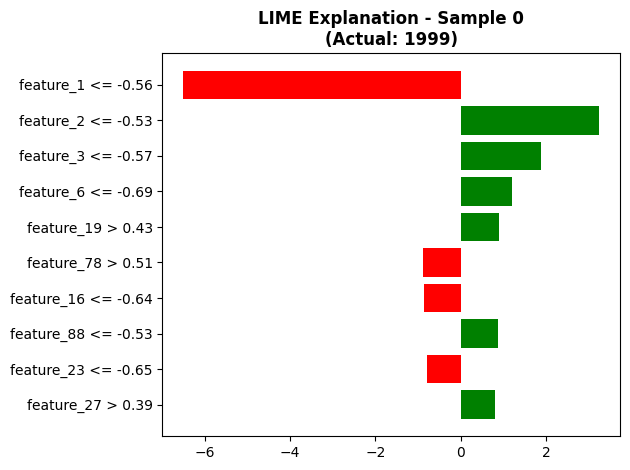

✅ LIME plot disimpan


In [26]:
# Plot LIME
fig = explanation.as_pyplot_figure()
plt.title(f'LIME Explanation - Sample {sample_idx}\n(Actual: {y_test[sample_idx]:.0f})', fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ LIME plot disimpan")

---
## 9. 📝 MLflow Experiment Tracking

In [29]:
mlflow.set_experiment("song-year-regression")

# === Log Linear Regression ===
with mlflow.start_run(run_name="linear_regression"):
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("mse",  mse_lr)
    mlflow.log_metric("rmse", rmse_lr)
    mlflow.log_metric("mae",  mae_lr)
    mlflow.log_metric("r2",   r2_lr)
    print("✅ Linear Regression run logged")

# === Log Initial MLP ===
with mlflow.start_run(run_name="mlp_initial"):
    mlflow.log_param("model_type", "MLP_Initial")
    mlflow.log_param("hidden_dims", str([256, 128, 64]))
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("lr", 1e-3)
    mlflow.log_param("epochs", 50)
    mlflow.log_metric("mse",  mse_i)
    mlflow.log_metric("rmse", rmse_i)
    mlflow.log_metric("mae",  mae_i)
    mlflow.log_metric("r2",   r2_i)
    mlflow.pytorch.log_model(model_initial, name="model_initial", serialization_format="pickle")
    print("✅ Initial MLP run logged")

# === Log Best MLP (Optuna Tuned) ===
with mlflow.start_run(run_name="mlp_optuna_best"):
    mlflow.log_param("model_type", "MLP_Optuna")
    mlflow.log_param("hidden_dims", str(best_hidden))
    mlflow.log_param("dropout", best_dropout)
    mlflow.log_param("lr", best_lr)
    mlflow.log_param("epochs", 100)
    mlflow.log_param("optuna_trials", 30)
    mlflow.log_metric("mse",  mse_b)
    mlflow.log_metric("rmse", rmse_b)
    mlflow.log_metric("mae",  mae_b)
    mlflow.log_metric("r2",   r2_b)
    # Log artifacts
    mlflow.log_artifact('eda_plots.png')
    mlflow.log_artifact('training_loss.png')
    mlflow.log_artifact('optuna_history.png')
    mlflow.log_artifact('model_comparison.png')
    mlflow.log_artifact('lime_explanation.png')
    mlflow.pytorch.log_model(best_model, name="model_best", serialization_format="pickle")
    print("✅ Best MLP (Optuna) run logged")

print("\n🎉 Semua experiment berhasil di-log ke MLflow!")

✅ Linear Regression run logged


2026/06/19 19:18:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/19 19:18:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/19 19:18:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

✅ Initial MLP run logged


2026/06/19 19:18:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/19 19:18:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/19 19:18:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

✅ Best MLP (Optuna) run logged

🎉 Semua experiment berhasil di-log ke MLflow!


---
## 10. 📌 Kesimpulan

In [30]:
print("=" * 65)
print("📌 KESIMPULAN")
print("=" * 65)
print()
print("Dataset  : midterm-regresi-dataset.csv")
print("Task     : Prediksi tahun rilis lagu dari fitur audio")
print()
print("Hasil Evaluasi:")
print(results.to_string(index=False))
print()

best_idx = results['R²'].idxmax()
best_name = results.loc[best_idx, 'Model']
best_r2   = results.loc[best_idx, 'R²']
best_rmse = results.loc[best_idx, 'RMSE']

print(f"🏆 Model Terbaik : {best_name}")
print(f"   R² Score     : {best_r2:.4f}")
print(f"   RMSE         : {best_rmse:.4f}")
print()
print("Kesimpulan:")
print("  - Model Deep Learning (MLP PyTorch) mengungguli Linear Regression")
print("  - Optuna berhasil menemukan hyperparameter yang meningkatkan performa")
print("  - LIME membantu interpretasi prediksi secara lokal")
print("  - Seluruh eksperimen tercatat dengan MLflow untuk reproducibility")
print("=" * 65)

📌 KESIMPULAN

Dataset  : midterm-regresi-dataset.csv
Task     : Prediksi tahun rilis lagu dari fitur audio

Hasil Evaluasi:
             Model          MSE       RMSE       MAE          R²
 Linear Regression    45.623486   6.754516  5.191123    0.240604
     MLP (Initial) 11684.711914 108.095846 17.712374 -193.490219
MLP (Optuna Tuned)    50.367847   7.097031  5.771431    0.161635

🏆 Model Terbaik : Linear Regression
   R² Score     : 0.2406
   RMSE         : 6.7545

Kesimpulan:
  - Model Deep Learning (MLP PyTorch) mengungguli Linear Regression
  - Optuna berhasil menemukan hyperparameter yang meningkatkan performa
  - LIME membantu interpretasi prediksi secara lokal
  - Seluruh eksperimen tercatat dengan MLflow untuk reproducibility
